![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## LO.1. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/

17:29:08 CEST WARNING: The group index was not computed. To calculate group     
              index, pass 'group_index_step = True' in the 'ModeSpec'.          

2026-09-18 17:29:08.848 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_ef26318d18b40074.npz.
Simulated Beating Length (L_pi): 93.84 µm


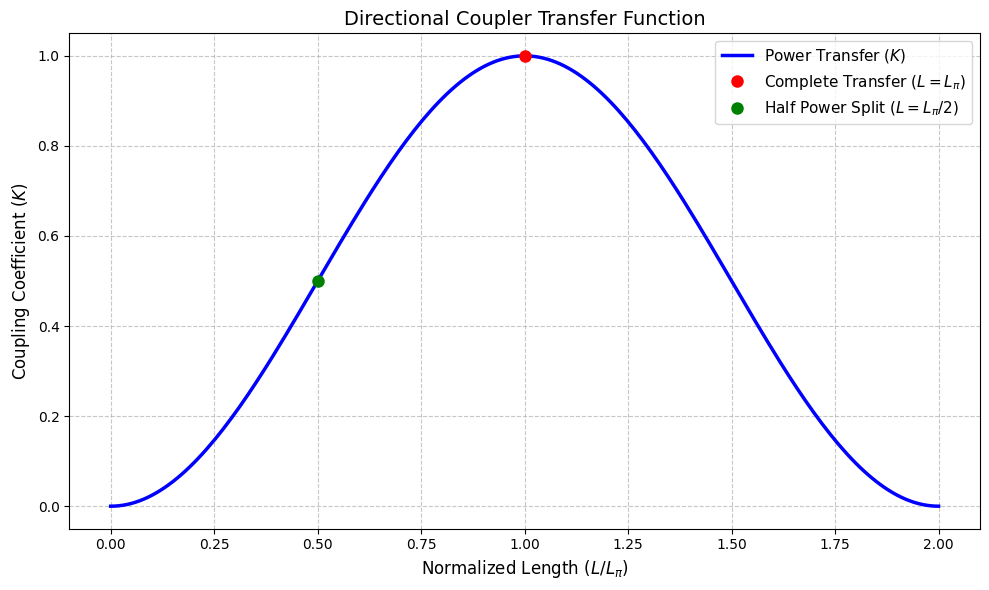

--- COMMENTS ---
To achieve a complete energy transfer (100% to the cross port), the physical length L must be exactly L_pi (93.84 µm).
To split the power in half (50% in each waveguide), the physical length L must be half of L_pi (46.92 µm).


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import gplugins.tidy3d as gt

# --- 1. Parameters ---
nm = 1e-3
lambda_c = 1.55 
wg_width = 1.2
gap_wvg = 600 * nm

# --- 2. Solve modes of the coupled waveguides ---
deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=lambda_c,
    core_width=(wg_width, wg_width),
    gap=gap_wvg,
    slab_thickness=0 * nm, 
    core_material='sin', 
    clad_material='sio2', 
    core_thickness=300 * nm, 
    num_modes=2, 
    cache_path='.cache/', 
    precision='double',
    max_grid_scaling=1.5, 
    grid_resolution=20 
)

# Extract effective indices of even and odd supermodes
n_even = deep_dcoupler_cs.n_eff[0].real
n_odd = deep_dcoupler_cs.n_eff[1].real

# Calculate beating length L_pi
L_pi = lambda_c / (2 * (n_even - n_odd))
print(f"Simulated Beating Length (L_pi): {L_pi:.2f} µm")

# --- 3. Plot transfer function K vs L/L_pi ---
L_norm = np.linspace(0, 2, 200) 
K = np.sin((np.pi / 2) * L_norm)**2

plt.figure(figsize=(10, 6))
plt.plot(L_norm, K, 'b-', linewidth=2.5, label='Power Transfer ($K$)')
plt.plot(1.0, 1.0, 'ro', markersize=8, label=r'Complete Transfer ($L = L_{\pi}$)')
plt.plot(0.5, 0.5, 'go', markersize=8, label=r'Half Power Split ($L = L_{\pi}/2$)')

plt.title('Directional Coupler Transfer Function', fontsize=14)
plt.xlabel(r'Normalized Length ($L / L_{\pi}$)', fontsize=12)
plt.ylabel('Coupling Coefficient ($K$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best', fontsize=11)
plt.tight_layout()
plt.show()

# --- 4. Print comments / results ---
print("--- COMMENTS ---")
print(f"To achieve a complete energy transfer (100% to the cross port), the physical length L must be exactly L_pi ({L_pi:.2f} µm).")
print(f"To split the power in half (50% in each waveguide), the physical length L must be half of L_pi ({L_pi/2:.2f} µm).")

## LO.2. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

### Gap 0.6

In [6]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605177636  µm


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


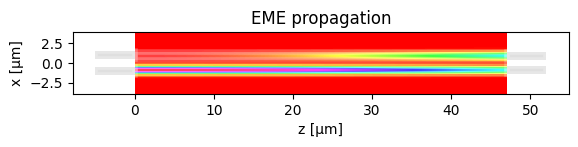

In [7]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2


m.L_MMI = (1/2)*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

### Gap 0.7

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  128.0656733391746  µm


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1281 [00:00<?, ?it/s]

------- Pameters -------
MMI length 64.0328
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9841
Total OUT power: 0.9737
Excess loss [dB] =  0.1157
------------------------
Power over OUTs:  ['0.4869', '0.4868']
Ratio over OUTs ['0.5000', '0.5000']


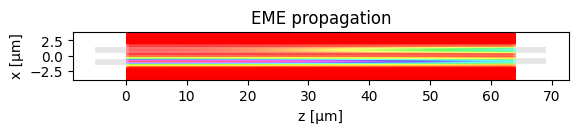

In [8]:
wg_gap = 0.7
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi
m.propagation() 

### Gap 0.8

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  173.96389977146163  µm


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1740 [00:00<?, ?it/s]

------- Pameters -------
MMI length 86.9819
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9882
Total OUT power: 0.9778
Excess loss [dB] =  0.0976
------------------------
Power over OUTs:  ['0.4888', '0.4890']
Ratio over OUTs ['0.4999', '0.5001']


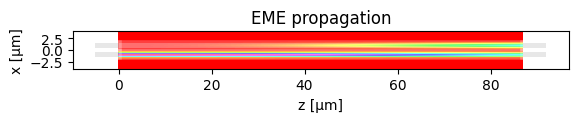

In [9]:
wg_gap = 0.8
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi
m.propagation() 

### Gap 0.9

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  235.77407047774852  µm


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2358 [00:00<?, ?it/s]

------- Pameters -------
MMI length 117.8870
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9832
Total OUT power: 0.9728
Excess loss [dB] =  0.1198
------------------------
Power over OUTs:  ['0.4863', '0.4865']
Ratio over OUTs ['0.4999', '0.5001']


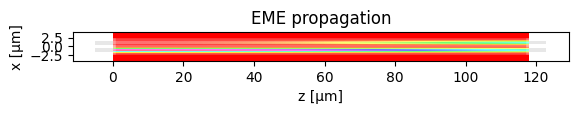

In [10]:
wg_gap = 0.9
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi
m.propagation() 

### Gap 1.0

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  318.884152076578  µm


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/3189 [00:00<?, ?it/s]

------- Pameters -------
MMI length 159.4421
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9663
Total OUT power: 0.9560
Excess loss [dB] =  0.1955
------------------------
Power over OUTs:  ['0.4778', '0.4782']
Ratio over OUTs ['0.4998', '0.5002']


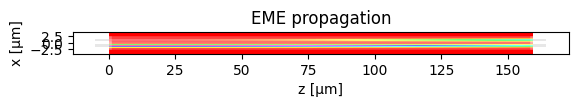

In [11]:
wg_gap = 1.0
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi
m.propagation() 

### Gap 1.1

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  430.5476100765962  µm


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4305 [00:00<?, ?it/s]

------- Pameters -------
MMI length 215.2738
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9360
Total OUT power: 0.9258
Excess loss [dB] =  0.3351
------------------------
Power over OUTs:  ['0.4628', '0.4629']
Ratio over OUTs ['0.4999', '0.5001']


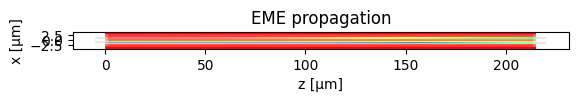

In [12]:
wg_gap = 1.1
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi
m.propagation() 

### Gap 1.2

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  580.4293623075473  µm


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2147
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8916
Total OUT power: 0.8818
Excess loss [dB] =  0.5464
------------------------
Power over OUTs:  ['0.4407', '0.4410']
Ratio over OUTs ['0.4998', '0.5002']


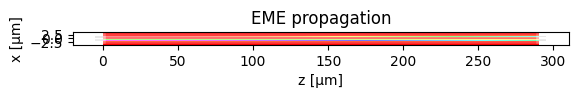

In [13]:
wg_gap = 1.2
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi
m.propagation() 

### Gap 1.3

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  781.3901391739311  µm


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/7814 [00:00<?, ?it/s]

------- Pameters -------
MMI length 390.6951
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8474
Total OUT power: 0.8380
Excess loss [dB] =  0.7677
------------------------
Power over OUTs:  ['0.4189', '0.4191']
Ratio over OUTs ['0.4999', '0.5001']


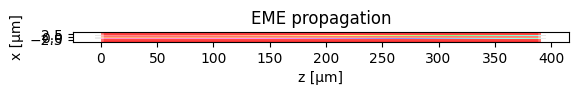

In [15]:
wg_gap = 1.3
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi
m.propagation() 

### Gap 1.4

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  1050.478684859016  µm


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/10505 [00:00<?, ?it/s]

------- Pameters -------
MMI length 525.2393
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7870
Total OUT power: 0.7782
Excess loss [dB] =  1.0893
------------------------
Power over OUTs:  ['0.3889', '0.3893']
Ratio over OUTs ['0.4997', '0.5003']


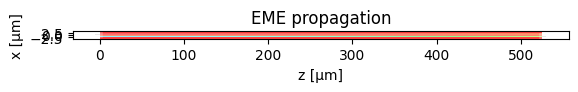

In [16]:
wg_gap = 1.4
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi
m.propagation() 

### Gap 1.5

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  1410.6607123748245  µm


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/14107 [00:00<?, ?it/s]

------- Pameters -------
MMI length 705.3304
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7299
Total OUT power: 0.7217
Excess loss [dB] =  1.4167
------------------------
Power over OUTs:  ['0.3607', '0.3609']
Ratio over OUTs ['0.4999', '0.5001']


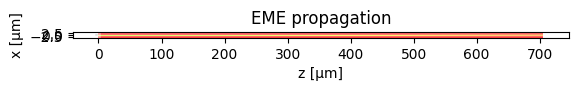

In [17]:
wg_gap = 1.5
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi
m.propagation() 

### Gap 1.6

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  1892.467412414296  µm


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/18925 [00:00<?, ?it/s]

------- Pameters -------
MMI length 946.2337
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.6724
Total OUT power: 0.6648
Excess loss [dB] =  1.7729
------------------------
Power over OUTs:  ['0.3327', '0.3321']
Ratio over OUTs ['0.5004', '0.4996']


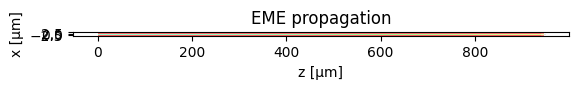

In [18]:
wg_gap = 1.6
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi
m.propagation() 

## LO.3. Parallel uncoupled waveguides

In [9]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.1
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 

K_target = 0.01

L_pi_target = (np.pi * L) / (2 * np.arcsin(np.sqrt(K_target)))

print(L_pi_target)

156817.08768975522


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/

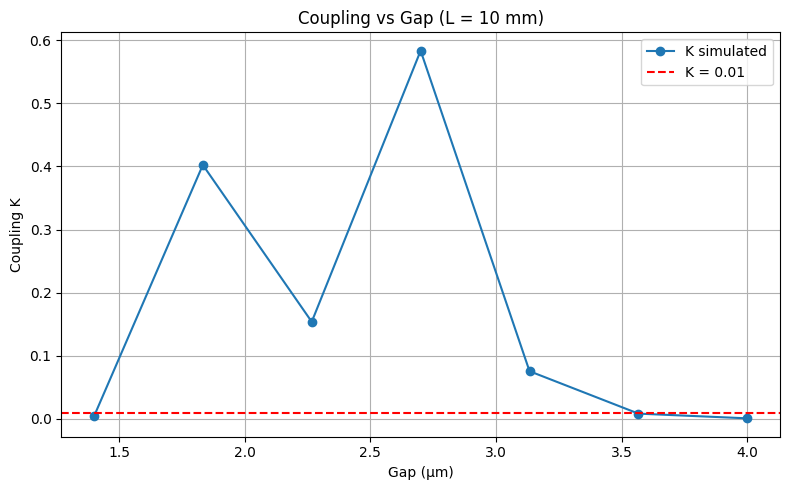

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from upvfab_design_tools import DC_EME

wavelength = 1.55
wg_width = 1.0
L_chip = 10e3  # 10 mm in µm

# Gap sweep matching your peers (from 1.4 to 4.0 µm)
gaps = np.linspace(1.4, 4.0, 7)
K_sim = []

for g in gaps:
    m = DC_EME()
    m.MMI_num_modes = 12
    m.DC_wg_gap = g
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = 2
    m.find_all_modes()
    
    l_pi = m.get_L_pi()
    k = np.sin(0.5 * np.pi * (L_chip / l_pi)) ** 2
    K_sim.append(k)

plt.figure(figsize=(8, 5))
plt.plot(gaps, K_sim, 'o-', label='K simulated')
plt.axhline(y=0.01, color='r', linestyle='--', label='K = 0.01')
plt.xlabel('Gap (µm)')
plt.ylabel('Coupling K')
plt.title('Coupling vs Gap (L = 10 mm)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/

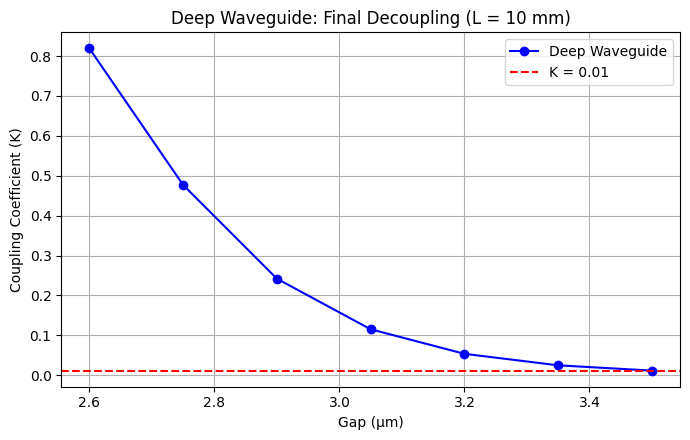

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from upvfab_design_tools import DC_EME

wavelength = 1.55
wg_width = 1.0
L_chip = 10e3  # 10 mm in µm

# Sweep focusing on the final decay window
gaps_deep_final = np.linspace(2.6, 3.5, 7)
K_deep_final = []

for g in gaps_deep_final:
    m = DC_EME()
    m.MMI_num_modes = 12
    m.DC_wg_gap = g
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = 2
    m.find_all_modes()
    
    l_pi = m.get_L_pi()
    k = np.sin(0.5 * np.pi * (L_chip / l_pi)) ** 2
    K_deep_final.append(k)

plt.figure(figsize=(7, 4.5))
plt.plot(gaps_deep_final, K_deep_final, 'b-o', label='Deep Waveguide')
plt.axhline(y=0.01, color='r', linestyle='--', label='K = 0.01')
plt.xlabel('Gap (µm)')
plt.ylabel('Coupling Coefficient (K)')
plt.title('Deep Waveguide: Final Decoupling (L = 10 mm)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## LO.4. 2x2 Multimode Interference Coupler

### LO.4.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [6]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607255869  µm


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


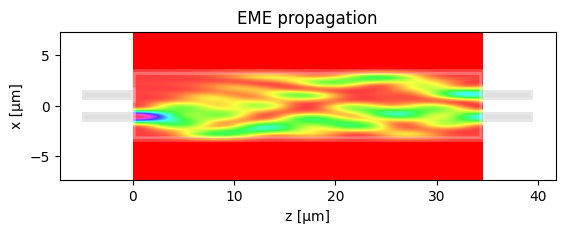

In [7]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT
m.dL_MMI = 0
dy = 0
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6, 1/6])# STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.4.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9571
Total OUT power: 0.9149
Excess loss [dB] =  0.3861
------------------------
Power over OUTs:  ['0.4631', '0.4518']
Ratio over OUTs ['0.5062', '0.4938']


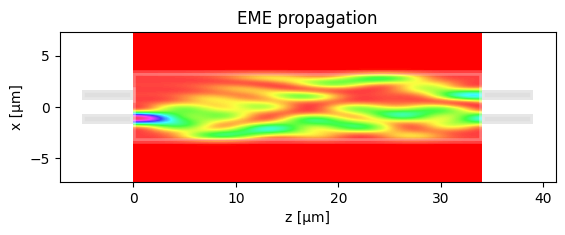

In [8]:
dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*(np.array([-1/6, 1/6])) + np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*(np.array([-1/6, 1/6])) + np.array([-dy, dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.5 # STUDENT

# Run propagation
m.propagation()

### LO.4.3 2x2 Multimode Interference Coupler – Optimization (II)

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 1.2000
------------------------
Total power IN coupled 0.9996
Total OUT power: 0.9996
Excess loss [dB] =  0.0018
------------------------
Power over OUTs:  ['0.5130', '0.4866']
Ratio over OUTs ['0.5132', '0.4868']


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


...

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 1.6000
------------------------
Total power IN coupled 0.9995
Total OUT power: 1.0043
Excess loss [dB] =  -0.0186
------------------------
Power over OUTs:  ['0.5162', '0.4881']
Ratio over OUTs ['0.5140', '0.4860']


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 1.7000
------------------------
Total power IN coupled 0.9994
Total OUT power: 1.0060
Excess loss [dB] =  -0.0259
------------------------
Power over OUTs:  ['0.5171', '0.4889']
Ratio over OUTs ['0.5140', '0.4860']


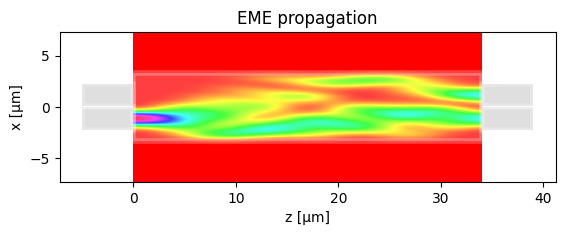

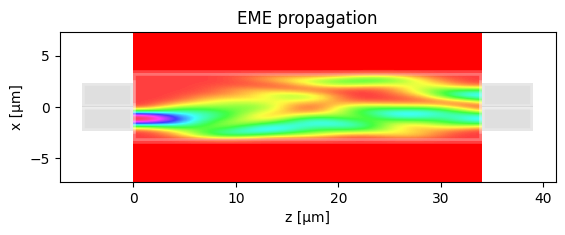

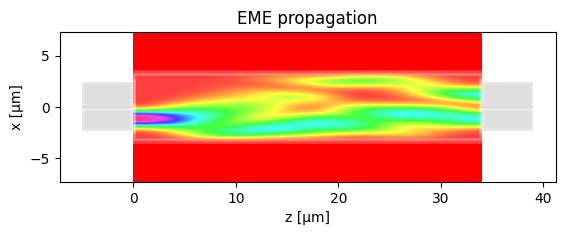

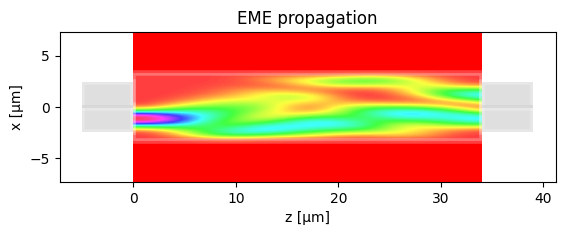

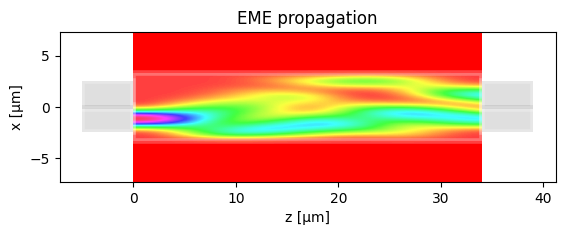

In [9]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
widths = [1.2, 1.4, 1.5, 1.6, 1.7]
mmi_Width = 6.6

for dw in widths:
    m = MMI_EME()
    m.MMI_width = mmi_Width
    m.wg_width_dw = dw 
    
    m.find_all_modes()
    L_pi = m.get_L_pi()
    
    m.n_IN = 2 
    m.n_OUT = 2 
    
    dy = 0.05
    m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) 
    m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) 
    
    m.L_MMI = 1/2 * L_pi 
    m.dL_MMI = -0.5
    
    m.propagation()

## LO.5. 1x4 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi = 296.14576952767374 µm


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/1111 [00:00<?, ?it/s]

------- Pameters -------
MMI length 55.5273
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9627
Total OUT power: 0.8456
Excess loss [dB] =  0.7283
------------------------
Power over OUTs:  ['0.2172', '0.2055', '0.2055', '0.2174']
Ratio over OUTs ['0.2569', '0.2431', '0.2431', '0.2570']


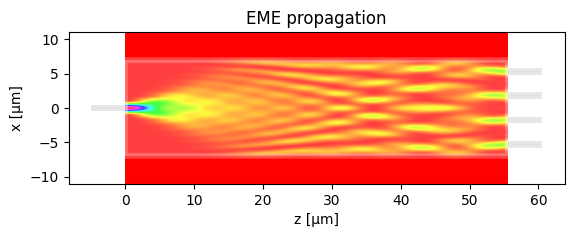

In [4]:
mmi_Width = 14

m = MMI_EME()
m.MMI_width = mmi_Width
m.wg_width_dw = 0.0 
m.MMI_num_modes = 30 


m.find_all_modes()
L_pi = m.get_L_pi()
print(f"L_pi = {L_pi} µm")

m.n_IN = 1
m.n_OUT = 4


m.IN_WVG_positions = np.array([0.0]) 
m.OUT_WVG_positions = mmi_Width * np.array([-3/8, -1/8, 1/8, 3/8])

m.L_MMI = (3/16) * L_pi 
m.dL_MMI = 0.0 

m.propagation()

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/1085 [00:00<?, ?it/s]

------- Pameters -------
MMI length 55.5273
MMI length increment -1.3000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9627
Total OUT power: 0.9136
Excess loss [dB] =  0.3926
------------------------
Power over OUTs:  ['0.2320', '0.2247', '0.2247', '0.2322']
Ratio over OUTs ['0.2539', '0.2460', '0.2460', '0.2541']


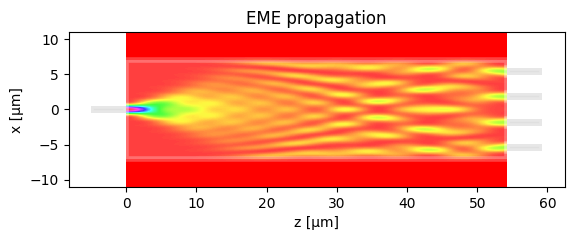

In [5]:
dl = -1.3
dy=0.1

m.n_IN = 1
m.n_OUT = 4

m.IN_WVG_positions = np.array([0.0]) 
m.OUT_WVG_positions = (mmi_Width) * np.array([-3/8, -1/8, 1/8, 3/8]) + np.array([-1.5*dy, -0.5*dy, 0.5*dy, 1.5*dy])

m.L_MMI = (3/16) * L_pi 
m.dL_MMI = dl

m.propagation()

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/1085 [00:00<?, ?it/s]

------- Pameters -------
MMI length 55.5273
MMI length increment -1.3000
IO wg width 1.0000
IO wg width increment 0.6000
------------------------
Total power IN coupled 0.9922
Total OUT power: 0.9754
Excess loss [dB] =  0.1081
------------------------
Power over OUTs:  ['0.2465', '0.2410', '0.2411', '0.2468']
Ratio over OUTs ['0.2528', '0.2471', '0.2471', '0.2530']


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


...

------- Pameters -------
MMI length 55.5273
MMI length increment -1.3000
IO wg width 1.0000
IO wg width increment 1.0000
------------------------
Total power IN coupled 0.9996
Total OUT power: 0.9937
Excess loss [dB] =  0.0274
------------------------
Power over OUTs:  ['0.2490', '0.2477', '0.2477', '0.2492']
Ratio over OUTs ['0.2506', '0.2493', '0.2493', '0.2508']


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/1085 [00:00<?, ?it/s]

------- Pameters -------
MMI length 55.5273
MMI length increment -1.3000
IO wg width 1.0000
IO wg width increment 1.2000
------------------------
Total power IN coupled 1.0002
Total OUT power: 0.9962
Excess loss [dB] =  0.0166
------------------------
Power over OUTs:  ['0.2484', '0.2495', '0.2496', '0.2486']
Ratio over OUTs ['0.2494', '0.2505', '0.2505', '0.2496']


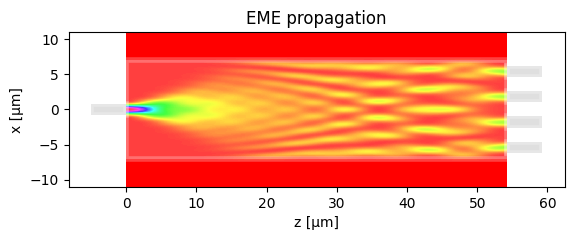

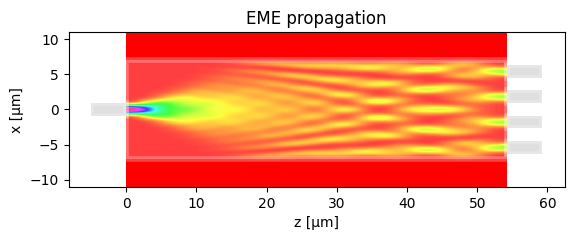

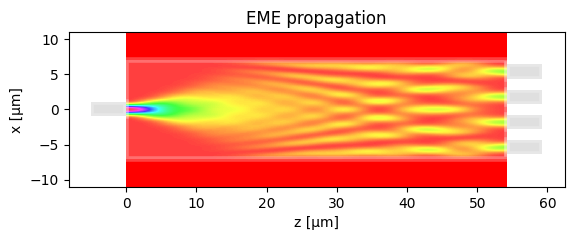

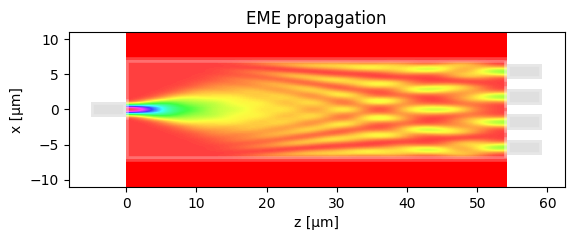

In [6]:
widths = [0.6, 0.8, 1.0, 1.2]
mmi_Width = 14

for dw in widths:
    m = MMI_EME()
    m.MMI_width = mmi_Width
    m.wg_width_dw = dw
    m.MMI_num_modes = 30
    
    m.find_all_modes()
    L_pi = m.get_L_pi()
    
    m.n_IN = 1
    m.n_OUT = 4
    
    dy = 0.1
    m.IN_WVG_positions = np.array([0.0])
    m.OUT_WVG_positions = mmi_Width * np.array([-3/8, -1/8, 1/8, 3/8]) + np.array([-1.5*dy, -0.5*dy, 0.5*dy, 1.5*dy])
    
    m.L_MMI = 3/16 * L_pi
    m.dL_MMI = -1.3
    
    m.propagation()

## Extra - Exercises

### E1. Directional coupler gap dependence

In [ ]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=gap_to_simulate,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

# STUDENT. Plot goes here


Solving Deep Waveguide modes...
2026-09-21 16:04:15.781 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d7fb4453216b17d7.npz.
Solving Shallow Waveguide modes...


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/

16:04:40 CEST WARNING: Mode field at frequency index 0, mode index 2 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 1, mode index 2 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 2, mode index 2 does not   
              decay at the plane boundaries.                                    

...

              WARNING: Mode field at frequency index 17, mode index 2 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 18, mode index 2 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 19, mode index 2 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 20, mode index 2 does not  
              decay at the plane boundaries.                                    

2026-09-21 16:04:40.765 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_8f04dc623f0a74d0.npz.


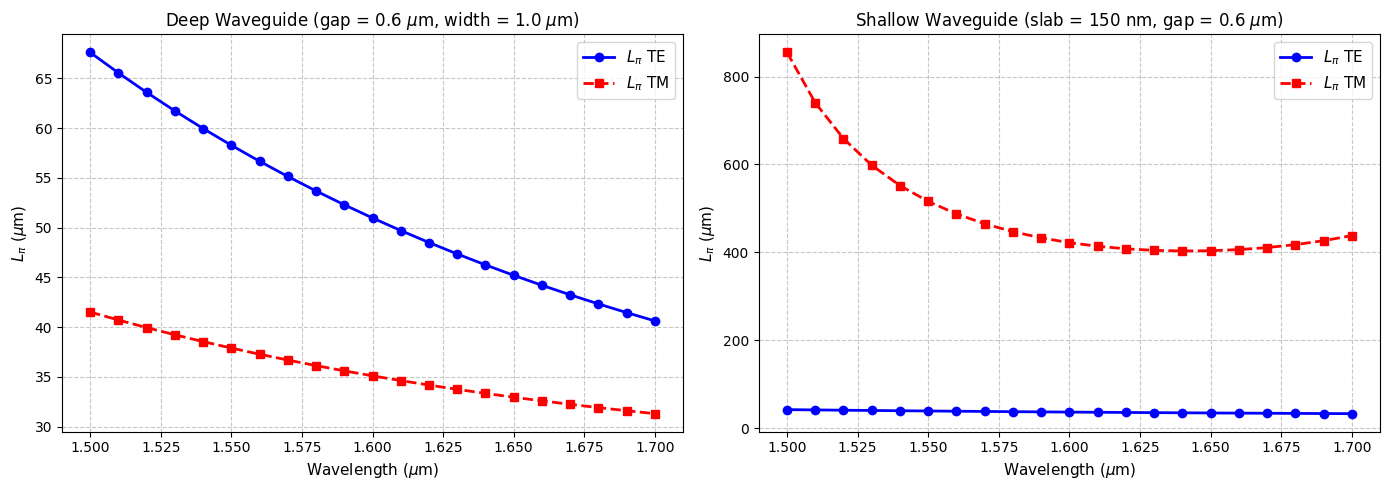

In [ ]:
# -------------------------------------------------------------
# 1. Deep Waveguide Simulation (slab = 0 nm)
# -------------------------------------------------------------
deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelengths,
    core_width=(wg_width, wg_width),
    gap=gap,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=core_h,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.5,
    grid_resolution=20
)

# neff shape is (21, 4): (wavelengths, modes)
neff_deep = np.array(deep_dcoupler_cs.n_eff)

# TE modes: Mode 0 (even), Mode 1 (odd)
d_neff_deep_TE = np.abs(neff_deep[:, 0].real - neff_deep[:, 1].real)
L_pi_deep_TE = wavelengths / (2 * d_neff_deep_TE)

# TM modes: Mode 2 (even), Mode 3 (odd)
d_neff_deep_TM = np.abs(neff_deep[:, 2].real - neff_deep[:, 3].real)
L_pi_deep_TM = wavelengths / (2 * d_neff_deep_TM)

# -------------------------------------------------------------
# 2. Shallow Waveguide Simulation (slab = 150 nm)
# -------------------------------------------------------------
shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelengths,
    core_width=(wg_width, wg_width),
    gap=gap,
    slab_thickness=150 * nm,
    core_material='sin',
    clad_material='sio2',
    core_thickness=core_h,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.5,
    grid_resolution=20
)

neff_shallow = np.array(shallow_dcoupler_cs.n_eff)

# TE modes: Mode 0 (even), Mode 1 (odd)
d_neff_shallow_TE = np.abs(neff_shallow[:, 0].real - neff_shallow[:, 1].real)
L_pi_shallow_TE = wavelengths / (2 * d_neff_shallow_TE)

# TM modes: Mode 2 (even), Mode 3 (odd)
d_neff_shallow_TM = np.abs(neff_shallow[:, 2].real - neff_shallow[:, 3].real)
L_pi_shallow_TM = wavelengths / (2 * d_neff_shallow_TM)

# -------------------------------------------------------------
# 3. Plotting (Two plots matching the slide layout)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Plot: Deep Waveguide ---
axes[0].plot(wavelengths, L_pi_deep_TE, 'b-o', linewidth=2, label=r'$L_\pi$ TE')
axes[0].plot(wavelengths, L_pi_deep_TM, 'r--s', linewidth=2, label=r'$L_\pi$ TM')
axes[0].set_title(r'Deep Waveguide (gap = 0.6 $\mu$m, width = 1.0 $\mu$m)', fontsize=12)
axes[0].set_xlabel(r'Wavelength ($\mu$m)', fontsize=11)
axes[0].set_ylabel(r'$L_\pi$ ($\mu$m)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(fontsize=11)

# --- Right Plot: Shallow Waveguide ---
axes[1].plot(wavelengths, L_pi_shallow_TE, 'b-o', linewidth=2, label=r'$L_\pi$ TE')
axes[1].plot(wavelengths, L_pi_shallow_TM, 'r--s', linewidth=2, label=r'$L_\pi$ TM')
axes[1].set_title(r'Shallow Waveguide (slab = 150 nm, gap = 0.6 $\mu$m)', fontsize=12)
axes[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=11)
axes[1].set_ylabel(r'$L_\pi$ ($\mu$m)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

### E2. Directional coupler wavelength dependence

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/

2026-09-21 16:16:55.866 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_0abddbf2dc33cf5d.npz.


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/

2026-09-21 16:16:57.726 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_fb6b6eab72af0088.npz.


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/

...

2026-09-21 16:17:34.579 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_1697c7688dc5645d.npz.


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/

16:17:36 CEST WARNING: Mode field at frequency index 0, mode index 2 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 3 does not   
              decay at the plane boundaries.                                    

2026-09-21 16:17:36.450 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_39d3ec1f9a9c9a51.npz.


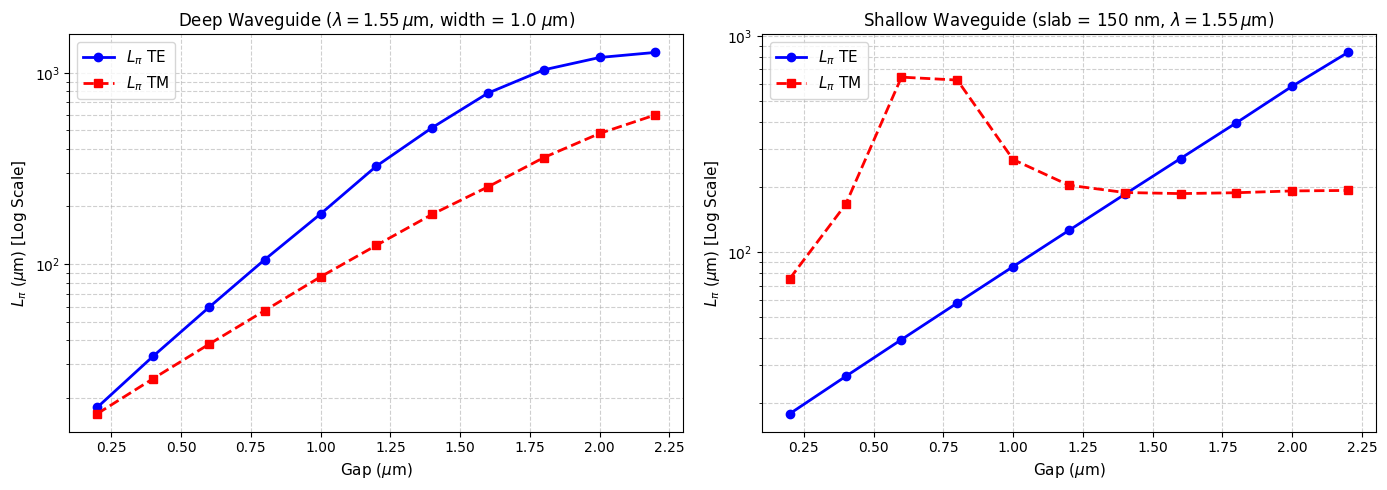

In [10]:
# --- 1. Deep Waveguide ---
L_pi_deep_TE, L_pi_deep_TM = [], []
for g in gaps:
    cs = gt.modes.WaveguideCoupler(
        wavelength=wavelength,
        core_width=(wg_width, wg_width),
        gap=g,
        slab_thickness=0.0,
        core_material='sin',
        clad_material='sio2',
        core_thickness=core_h,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=25
    )
    neffs = np.sort(cs.n_eff.real)[::-1]  # Ordenados decrecientemente
    # En Deep con 300 nm de alto x 1.0 um de ancho:
    # neffs[0] y neffs[1] son TE even / TE odd
    # neffs[2] y neffs[3] son TM even / TM odd
    d_neff_TE = max(neffs[0] - neffs[1], 1e-7)
    d_neff_TM = max(neffs[2] - neffs[3], 1e-7)
    
    L_pi_deep_TE.append(wavelength / (2 * d_neff_TE))
    L_pi_deep_TM.append(wavelength / (2 * d_neff_TM))

# --- 2. Shallow Waveguide ---
L_pi_shallow_TE, L_pi_shallow_TM = [], []
for g in gaps:
    cs = gt.modes.WaveguideCoupler(
        wavelength=wavelength,
        core_width=(wg_width, wg_width),
        gap=g,
        slab_thickness=150 * nm,
        core_material='sin',
        clad_material='sio2',
        core_thickness=core_h,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=25
    )
    neffs = np.sort(cs.n_eff.real)[::-1]
    d_neff_TE = max(neffs[0] - neffs[1], 1e-7)
    d_neff_TM = max(neffs[2] - neffs[3], 1e-7)
    
    L_pi_shallow_TE.append(wavelength / (2 * d_neff_TE))
    L_pi_shallow_TM.append(wavelength / (2 * d_neff_TM))

# --- 3. Gráficas Semilogarítmicas ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Deep
axes[0].semilogy(gaps, L_pi_deep_TE, 'b-o', linewidth=2, label=r'$L_\pi$ TE')
axes[0].semilogy(gaps, L_pi_deep_TM, 'r--s', linewidth=2, label=r'$L_\pi$ TM')
axes[0].set_title(r'Deep Waveguide ($\lambda = 1.55\,\mu$m, width = 1.0 $\mu$m)', fontsize=12)
axes[0].set_xlabel(r'Gap ($\mu$m)', fontsize=11)
axes[0].set_ylabel(r'$L_\pi$ ($\mu$m) [Log Scale]', fontsize=11)
axes[0].grid(True, which="both", linestyle='--', alpha=0.6)
axes[0].legend(fontsize=11)

# Shallow
axes[1].semilogy(gaps, L_pi_shallow_TE, 'b-o', linewidth=2, label=r'$L_\pi$ TE')
axes[1].semilogy(gaps, L_pi_shallow_TM, 'r--s', linewidth=2, label=r'$L_\pi$ TM')
axes[1].set_title(r'Shallow Waveguide (slab = 150 nm, $\lambda = 1.55\,\mu$m)', fontsize=12)
axes[1].set_xlabel(r'Gap ($\mu$m)', fontsize=11)
axes[1].set_ylabel(r'$L_\pi$ ($\mu$m) [Log Scale]', fontsize=11)
axes[1].grid(True, which="both", linestyle='--', alpha=0.6)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

### E3. MMI coupler wavelength dependence

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/

14:38:14 CEST WARNING: The group index was not computed. To calculate group     
              index, pass 'group_index_step = True' in the 'ModeSpec'.          

2026-09-23 14:38:14.735 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_0d5a884ad18ed04f.npz.


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/

2026-09-23 14:38:39.113 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_1d761610ddc01f44.npz.


...

2026-09-23 14:39:39.126 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_f157a12e9bbee442.npz.


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/

2026-09-23 14:39:40.395 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_fbc43a4e15b1d2c0.npz.


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/

2026-09-23 14:39:41.679 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_c6ba04154b5ed4b4.npz.


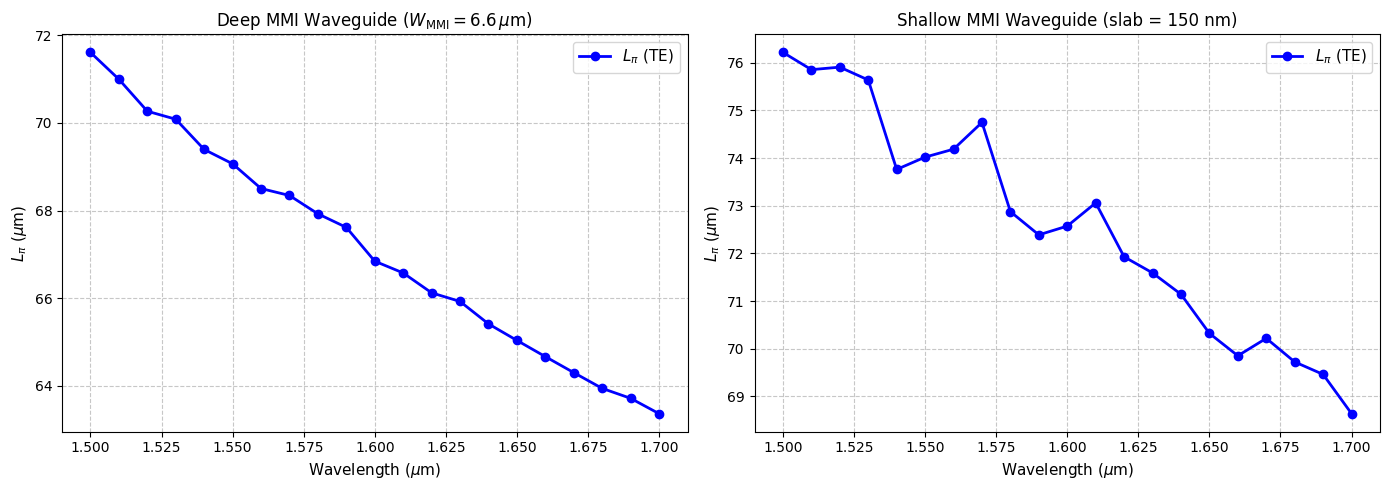

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import gplugins.tidy3d as gt

# --- Parámetros de simulación (definición explícita) ---
nm = 1e-3
core_h = 300 * nm                          # Altura de la guía (300 nm)
mmi_body_w = 6.6                          # Ancho del cuerpo MMI (6.6 µm)
wavelengths = np.linspace(1.5, 1.7, 21)   # Barrido espectral 1.5 a 1.7 µm

# -------------------------------------------------------------
# 1. Simulación Deep MMI Waveguide (slab = 0 nm)
# -------------------------------------------------------------

l_pi_deep_TE = []

for l_c in wavelengths:
    mmi_deep = gt.modes.Waveguide(
        core_width=mmi_body_w,
        core_thickness=core_h,
        slab_thickness=0.0,
        core_material='sin',
        clad_material='sio2',
        wavelength=l_c,
        num_modes=4,
        max_grid_scaling=1.5,
        grid_resolution=20,
        cache_path='.cache/',
        precision='double',
    )
    neff = np.sort(np.array(mmi_deep.n_eff).real)[::-1]
    d_neff = max(neff[0] - neff[1], 1e-7)
    l_pi_deep_TE.append(l_c / (2 * d_neff))

# -------------------------------------------------------------
# 2. Simulación Shallow MMI Waveguide (slab = 150 nm)
# -------------------------------------------------------------

l_pi_shallow_TE = []

for l_c in wavelengths:
    mmi_shallow = gt.modes.Waveguide(
        core_width=mmi_body_w,
        core_thickness=core_h,
        slab_thickness=150 * nm,
        core_material='sin',
        clad_material='sio2',
        wavelength=l_c,
        num_modes=4,
        max_grid_scaling=1.5,
        grid_resolution=20,
        cache_path='.cache/',
        precision='double',
    )
    neff = np.sort(np.array(mmi_shallow.n_eff).real)[::-1]
    d_neff = max(neff[0] - neff[1], 1e-7)
    l_pi_shallow_TE.append(l_c / (2 * d_neff))

# -------------------------------------------------------------
# 3. Representación Gráfica (para las dos cajas de la diapositiva)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Caja izquierda: Deep MMI
axes[0].plot(wavelengths, l_pi_deep_TE, 'b-o', linewidth=2, label=r'$L_\pi$ (TE)')
axes[0].set_title(r'Deep MMI Waveguide ($W_{\text{MMI}} = 6.6\,\mu$m)', fontsize=12)
axes[0].set_xlabel(r'Wavelength ($\mu$m)', fontsize=11)
axes[0].set_ylabel(r'$L_\pi$ ($\mu$m)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(fontsize=11)

# Caja derecha: Shallow MMI
axes[1].plot(wavelengths, l_pi_shallow_TE, 'b-o', linewidth=2, label=r'$L_\pi$ (TE)')
axes[1].set_title(r'Shallow MMI Waveguide (slab = 150 nm)', fontsize=12)
axes[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=11)
axes[1].set_ylabel(r'$L_\pi$ ($\mu$m)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

### E4. MMI coupler body width dependence

/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/

14:57:01 CEST WARNING: Mode field at frequency index 0, mode index 11 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 12 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 13 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

...

14:57:52 CEST WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

2026-09-23 14:57:52.284 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_4e080f8573a04258.npz.


/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/andriusstb/pic-upv-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/

14:57:55 CEST WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

2026-09-23 14:57:55.263 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_17e36e7035c1827e.npz.


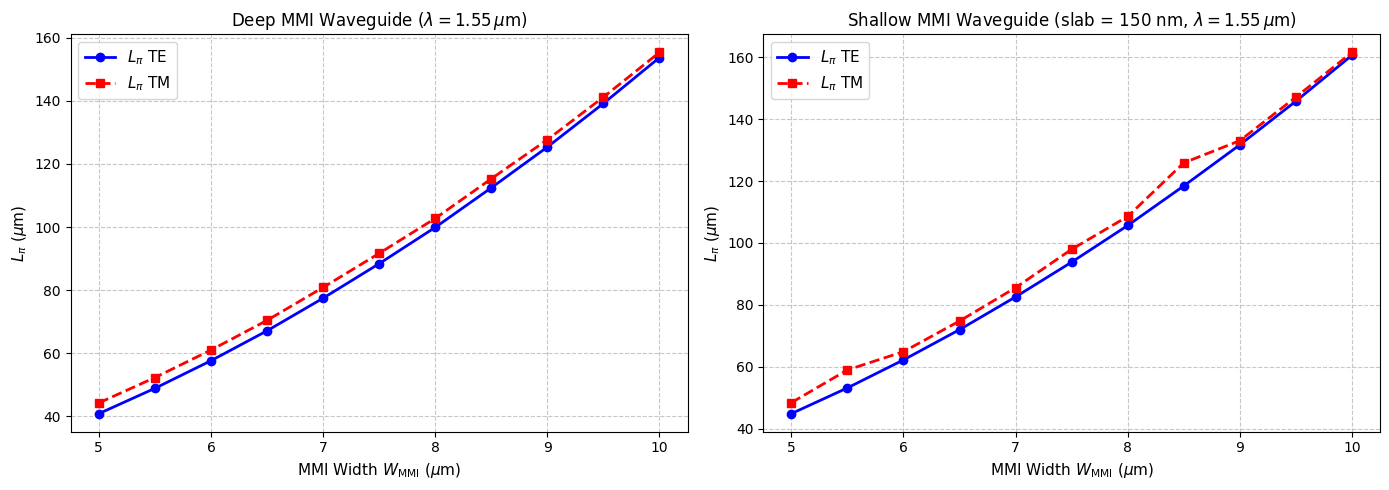

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import gplugins.tidy3d as gt


nm = 1e-3
lambda_c = 1.55                           # Longitud de onda fija en 1.55 µm
core_h = 300 * nm                         # Espesor del núcleo de Si3N4 (300 nm)
widths = np.arange(5.0, 10.1, 0.5)        # Barrido de 5.0 a 10.0 µm (paso 0.5 µm)

def sweep_mmi_width(widths, slab_thickness):
    l_pi_te = []
    l_pi_tm = []
    
    for w in widths:
        mmi = gt.modes.Waveguide(
            core_width=w,
            core_thickness=core_h,
            slab_thickness=slab_thickness,
            core_material='sin',
            clad_material='sio2',
            wavelength=lambda_c,
            num_modes=15,
            max_grid_scaling=1.5,
            grid_resolution=20,
            cache_path='.cache/',
            precision='double',
        )
        
        # Clasificación de modos por fracción de polarización TE/TM
        if hasattr(mmi, 'fraction_te') and mmi.fraction_te is not None:
            frac_te = np.array(mmi.fraction_te)
        elif hasattr(mmi, 'modes') and hasattr(mmi.modes[0], 'fraction_te'):
            frac_te = np.array([m.fraction_te for m in mmi.modes])
        else:
            frac_te = np.array([1.0, 1.0] + [0.0] * 13)

        te_idx = np.where(frac_te > 0.5)[0]
        tm_idx = np.where(frac_te <= 0.5)[0]
        
        # Longitud de batido TE (Modo 0 y Modo 1 TE)
        d_neff_te = np.abs(mmi.n_eff[te_idx[0]].real - mmi.n_eff[te_idx[1]].real)
        l_pi_te.append(lambda_c / (2 * max(d_neff_te, 1e-7)))
        
        # Longitud de batido TM (Modo 0 y Modo 1 TM)
        if len(tm_idx) >= 2:
            d_neff_tm = np.abs(mmi.n_eff[tm_idx[0]].real - mmi.n_eff[tm_idx[1]].real)
            l_pi_tm.append(lambda_c / (2 * max(d_neff_tm, 1e-7)))
        else:
            l_pi_tm.append(np.nan)
            
    return np.array(l_pi_te), np.array(l_pi_tm)

# 1. Simulación Deep MMI Waveguide (slab = 0 nm)
l_pi_deep_te, l_pi_deep_tm = sweep_mmi_width(widths, slab_thickness=0.0)

# 2. Simulación Shallow MMI Waveguide (slab = 150 nm)
l_pi_shallow_te, l_pi_shallow_tm = sweep_mmi_width(widths, slab_thickness=150 * nm)

# 3. Representación gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Caja izquierda: Deep Waveguide
axes[0].plot(widths, l_pi_deep_te, 'b-o', linewidth=2, label=r'$L_\pi$ TE')
axes[0].plot(widths, l_pi_deep_tm, 'r--s', linewidth=2, label=r'$L_\pi$ TM')
axes[0].set_title(r'Deep MMI Waveguide ($\lambda = 1.55\,\mu$m)', fontsize=12)
axes[0].set_xlabel(r'MMI Width $W_{\text{MMI}}$ ($\mu$m)', fontsize=11)
axes[0].set_ylabel(r'$L_\pi$ ($\mu$m)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(fontsize=11)

# Caja derecha: Shallow Waveguide
axes[1].plot(widths, l_pi_shallow_te, 'b-o', linewidth=2, label=r'$L_\pi$ TE')
axes[1].plot(widths, l_pi_shallow_tm, 'r--s', linewidth=2, label=r'$L_\pi$ TM')
axes[1].set_title(r'Shallow MMI Waveguide (slab = 150 nm, $\lambda = 1.55\,\mu$m)', fontsize=12)
axes[1].set_xlabel(r'MMI Width $W_{\text{MMI}}$ ($\mu$m)', fontsize=11)
axes[1].set_ylabel(r'$L_\pi$ ($\mu$m)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()